¡Estructura conectada con éxito!


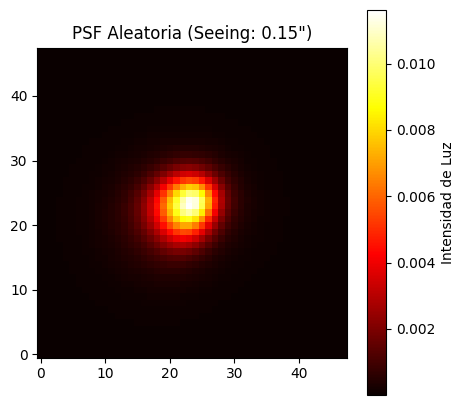

In [17]:
import os
import sys

# Corregimos la ruta dinámicamente para encontrar la carpeta 'src'
ruta_actual = os.getcwd()
if ruta_actual.endswith('notebooks'):
    ruta_raiz = os.path.abspath(os.path.join(ruta_actual, '..'))
else:
    ruta_raiz = ruta_actual

if ruta_raiz not in sys.path:
    sys.path.insert(0, ruta_raiz)

# Importamos las librerías gráficas y TU script generador
import matplotlib.pyplot as plt
from src.psf_generator import generate_combined_psf

print("¡Estructura conectada con éxito!")

# 1. Generamos una PSF aleatoria usando tu función
psf_matrix, info = generate_combined_psf()

# 2. La graficamos para inspección visual
plt.figure(figsize=(5, 5))
plt.imshow(psf_matrix, cmap='hot', origin='lower')
plt.title(f"PSF Aleatoria (Seeing: {info['fwhm_atmos']:.2f}\")")
plt.colorbar(label='Intensidad de Luz')
plt.show()

In [18]:
import os
import numpy as np
from src.psf_generator import generate_combined_psf

# 1. Crear una carpeta temporal para la prueba
os.makedirs("data_prueba", exist_ok=True)

# 2. Generar y guardar 3 pares de imágenes (Sucia/Limpia)
# Nota: Para esta prueba rápida usaremos la misma PSF como sucia y una matriz aleatoria como limpia
for i in range(3):
    psf_dirty, _ = generate_combined_psf()
    galaxy_clean = np.random.rand(48, 48) # Simulamos una galaxia limpia aleatoria
    
    # Las guardamos con el formato exacto que busca tu dataset.py
    np.save(f"data_prueba/dirty_{i:04d}.npy", psf_dirty)
    np.save(f"data_prueba/clean_{i:04d}.npy", galaxy_clean)

print("¡Imágenes de prueba guardadas con éxito en 'data_prueba/'!")

¡Imágenes de prueba guardadas con éxito en 'data_prueba/'!


In [19]:
import torch
from torch.utils.data import DataLoader
from src.dataset import AstronomyDataset

# 1. Instanciamos tu dataset apuntando a la carpeta de prueba
dataset = AstronomyDataset(data_dir="data_prueba")
print(f"El dataset leyó correctamente el inventario. Total de imágenes: {len(dataset)}")

# 2. Creamos el DataLoader (Pediremos lotes de 2 en 2)
test_loader = DataLoader(dataset, batch_size=2, shuffle=True)

El dataset leyó correctamente el inventario. Total de imágenes: 3


In [20]:
# Tomamos el primer lote de la fábrica automatizada
dirty_batch, clean_batch = next(iter(test_loader))

print("=== VERIFICACIÓN DE TENSORES EN PYTORCH ===")
print(f"Forma del lote sucio (Batch, Canal, Alto, Ancho): {dirty_batch.shape}")
print(f"Forma del lote limpio (Batch, Canal, Alto, Ancho): {clean_batch.shape}")
print(f"Tipo de datos interno: {dirty_batch.dtype}")

=== VERIFICACIÓN DE TENSORES EN PYTORCH ===
Forma del lote sucio (Batch, Canal, Alto, Ancho): torch.Size([2, 1, 48, 48])
Forma del lote limpio (Batch, Canal, Alto, Ancho): torch.Size([2, 1, 48, 48])
Tipo de datos interno: torch.float32
